<a href="https://colab.research.google.com/github/haritha100/PIIDetection-and-Analysis/blob/main/CustomSolution_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
## Import required libraries

import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# Libraries to train and evaluate model
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


import tensorflow as tf
from tqdm import tqdm


from sklearn.preprocessing import LabelEncoder


from keras.models import Sequential
from keras.layers import LSTM, GRU,SimpleRNN, Dense, Activation, Dropout, Embedding, BatchNormalization
from keras import regularizers
from keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn import preprocessing, decomposition, model_selection, metrics, pipeline
from keras.layers import GlobalMaxPooling1D, Conv1D, MaxPooling1D, Flatten, Bidirectional, SpatialDropout1D

from nltk.tokenize import word_tokenize,sent_tokenize
import pickle

import warnings
warnings.filterwarnings('ignore')

In [6]:
tf.__version__

'2.20.0'

In [7]:
pii_df = pd.read_json('/content/drive/My Drive/AIML/projects/Hackathon/Dataset_privy/dev-small.json')

FileNotFoundError: File /content/drive/My Drive/AIML/projects/Hackathon/Dataset_privy/dev-small.json does not exist

In [ ]:
pii_df.head()

,full_text,masked,spans,tags,tokens,template_id,metadata
0,"{""id"": ""16fab7b08816d720fee9378bb34b384f52e1df...","{""id"": ""{{sha1}}"", ""family name female"": ""{{la...","[{'entity_type': 'PER', 'entity_value': 'Roman...","[O, O, O, O, O, O, O, U-O, O, O, O, O, O, O, O...","[{, "", i, d, "", :, "", 16fab7b08816d720fee9378b...",99244,NaN
1,"{""month"": ""08"", ""identity document"": ""X5943991...","{""month"": ""{{month}}"", ""identity document"": ""{...","[{'entity_type': 'DATE_TIME', 'entity_value': ...","[O, O, O, O, O, O, U-DATE_TIME, O, O, O, O, O,...","[{, "", month, "", :, "", 08, "", ,, "", identity, ...",83829,NaN
2,"<table border=""1""><tr><th>street</th><td>00921...","<table border=""1""><tr><th>street</th><td>{{str...","[{'entity_type': 'LOC', 'entity_value': '424 2...","[O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, ...","[<, table, border, =, "", 1, "", >, <, tr, >, <,...",119537,NaN
3,"b'<?xml version=""1.0"" encoding=""UTF-8"" ?><root...","b'<?xml version=""1.0"" encoding=""UTF-8"" ?><root...","[{'entity_type': 'O', 'entity_value': '', 'sta...","[O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, ...","[b, ', <, ?xml, version, =, "", 1.0, "", encodin...",13859,NaN
4,"<table border=""1""><tr><th>resourceGroupName</t...","<table border=""1""><tr><th>resourceGroupName</t...","[{'entity_type': 'O', 'entity_value': '', 'sta...","[O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, ...","[<, table, border, =, "", 1, "", >, <, tr, >, <,...",128513,NaN


In [ ]:
pii_df.columns.tolist()

['full_text', 'masked', 'spans', 'tags', 'tokens', 'template_id', 'metadata']

In [ ]:
ner_df = pii_df.copy(deep=True)

In [ ]:
ner_df.drop(['spans', 'tags', 'tokens', 'template_id', 'metadata'], inplace=True, axis=1)

In [ ]:
ner_df

,full_text,masked
0,"{""id"": ""16fab7b08816d720fee9378bb34b384f52e1df...","{""id"": ""{{sha1}}"", ""family name female"": ""{{la..."
1,"{""month"": ""08"", ""identity document"": ""X5943991...","{""month"": ""{{month}}"", ""identity document"": ""{..."
2,"<table border=""1""><tr><th>street</th><td>00921...","<table border=""1""><tr><th>street</th><td>{{str..."
3,"b'<?xml version=""1.0"" encoding=""UTF-8"" ?><root...","b'<?xml version=""1.0"" encoding=""UTF-8"" ?><root..."
4,"<table border=""1""><tr><th>resourceGroupName</t...","<table border=""1""><tr><th>resourceGroupName</t..."
...,...,...
14417,"<table border=""1""><tr><th>nation_woman</th><td...","<table border=""1""><tr><th>nation_woman</th><td..."
14418,"INSERT INTO ""expect"" (""swift_code,ClientVpnEnd...","INSERT INTO ""expect"" (""swift_code,ClientVpnEnd..."
14419,"b'<?xml version=""1.0"" encoding=""UTF-8"" ?><root...","b'<?xml version=""1.0"" encoding=""UTF-8"" ?><root..."
14420,"b'<?xml version=""1.0"" encoding=""utf-8"" ?><root...","b'<?xml version=""1.0"" encoding=""UTF-8"" ?><root..."


In [ ]:
!pip install contractions

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 289.9/289.9 kB 7.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.8/110.8 kB 17.0 MB/s eta 0:00:00


In [ ]:
import re
import nltk
import contractions
nltk.download('punkt')
nltk.download('all')

from nltk.corpus import stopwords
from nltk import word_tokenize
# Used in Lemmatization
from nltk.stem import WordNetLemmatizer

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/abc.zip.
[nltk_data]    | Downloading package alpino to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/alpino.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping
[nltk_data]    |       taggers/averaged_perceptron_tagger_ru.zip.
[nltk_data]    | Downloading package basque_grammars to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping grammars/basque_grammars.zip.
[nltk_data]    | Downloading package bcp47 to /root/nltk_data...
[nltk_data

In [ ]:

# function for text pre-processing
def clean_text(df, punctuations=r'''!()-[]{};:'"\,<>./?@#$%^&*_~'''):
    """
    A method to clean text
    """
    # Cleaning the urls
    string = re.sub(r'https?://\S+|www\.\S+', '', df)

    # Cleaning the html elements
    string = re.sub(r'<.*?>', '', df)

    # Removing the punctuations using regular expression
    # i.e remove anything which is not word or whitespace character

    string = re.sub(r'[^\w\s]', '', df)

    # Converting the text to lower
    string = string.lower()

    # Removing stop words
    string = ' '.join([word for word in string.split() if word not in stopwords.words('english')])

    # Cleaning the whitespaces
    string = re.sub(r'\s+', ' ', string).strip()

    #tokenize data
    string = word_tokenize(string)

    #remove number
    string=[s for s in string if s.isalpha()]

    #lemmatize the data
    string= [WordNetLemmatizer().lemmatize(i) for i in string]

    #fix contractions (example: "'cause": "because","could've": "could have",etc)
    string = ' '.join([contractions.fix(word) for word in string])


    return string
    #return " ".join(string)


In [ ]:
ner_df["full_text"] = ner_df["full_text"].astype(str)
ner_df['clean_text'] = ner_df['full_text'].apply(clean_text)

ner_df["masked"] = ner_df["masked"].astype(str)
ner_df['clean_mtext'] = ner_df['masked'].apply(clean_text)

ner_df.head(5)

,full_text,masked,clean_text,clean_mtext
0,"{""id"": ""16fab7b08816d720fee9378bb34b384f52e1df...","{""id"": ""{{sha1}}"", ""family name female"": ""{{la...",id family name female roman,id family name female
1,"{""month"": ""08"", ""identity document"": ""X5943991...","{""month"": ""{{month}}"", ""identity document"": ""{...",month identity document idnumber workloadid en...,month month identity document passport year id...
2,"<table border=""1""><tr><th>street</th><td>00921...","<table border=""1""><tr><th>street</th><td>{{str...",table hillcrest avenue apt westwood avenue new...,table
3,"b'<?xml version=""1.0"" encoding=""UTF-8"" ?><root...","b'<?xml version=""1.0"" encoding=""UTF-8"" ?><root...",bxml rootpassport typestrstatusmaxresults type...,bxml rootpassport typestrstringstatusmaxresult...
4,"<table border=""1""><tr><th>resourceGroupName</t...","<table border=""1""><tr><th>resourceGroupName</t...",table,table


In [ ]:
ner_df.to_json("/content/drive/My Drive/AIML/projects/Hackathon/Dataset_privy/cleaneddata.json")

In [ ]:
txtData = ner_df.clean_text
print("Max length of the description = ", txtData.apply(lambda x: len(str(x).split())).max())

Max length of the description =  110


In [ ]:
y = LabelEncoder().fit_transform(ner_df['clean_mtext']).astype(np.int8)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(txtData, y, test_size=0.2, stratify=y, random_state=31)
y_train_encoded = pd.get_dummies(y_train)
y_test_encoded = pd.get_dummies(y_test)

In [ ]:
token = text.Tokenizer(num_words=None)
max_len = 185

token.fit_on_texts(list(X_train) + list(X_test))
X_train_seq = token.texts_to_sequences(X_train)
X_test_seq = token.texts_to_sequences(X_test)


In [ ]:
X_train_pad = pad_sequences(X_train_seq, maxlen = max_len)
X_test_pad = pad_sequences(X_test_seq, maxlen = max_len)
word_index = token.word_index

In [ ]:
embeddings_index = {}
f = open('/content/drive/My Drive/AIML/projects/Hackathon/Dataset_privy/glove.6B.300d.txt','r',encoding='utf-8')
for line in tqdm(f):
    values = line.split(' ')
    word = values[0]
    coefs = np.asarray([float(val) for val in values[1:]])
    embeddings_index[word] = coefs
f.close()

print('Found %s word vectors.' % len(embeddings_index))

400000it [00:31, 12711.94it/s]

Found 400000 word vectors.


In [ ]:
embedding_matrix = np.zeros((len(word_index) + 1, 300))
for word, i in tqdm(word_index.items()):
    embedding_vector = embeddings_index.get(word)
    if embedding_vector is not None:
        embedding_matrix[i] = embedding_vector

In [ ]:
model = Sequential()
model.add(Embedding(len(word_index) + 1, 300, weights=[embedding_matrix],input_length=max_len,trainable=False))
model.add(LSTM(1024, return_sequences=True))#, dropout=0.3, recurrent_dropout=0.3))
model.add(LSTM(512, return_sequences=True))
model.add(LSTM(256))
model.add(Dense(256, activation='softmax'))
model.compile(loss='categorical_crossentropy', optimizer='adam',metrics=['accuracy'])
early_stopping = EarlyStopping(monitor='val_loss', patience=5,restore_best_weights=True)
model.summary()

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_4 (Embedding)     (None, 185, 300)          8865300   
                                                                 
 lstm_12 (LSTM)              (None, 185, 1024)         5427200   
                                                                 
 lstm_13 (LSTM)              (None, 185, 512)          3147776   
                                                                 
 lstm_14 (LSTM)              (None, 256)               787456    
                                                                 
 dense_4 (Dense)             (None, 256)               65792     
                                                                 
Total params: 18,293,524
Trainable params: 9,428,224
Non-trainable params: 8,865,300
_________________________________________________________________


In [ ]:
history = model.fit(X_train_pad, y_train_encoded, epochs=50, batch_size=32, validation_data=
                    (X_test_pad, y_test_encoded), callbacks=[early_stopping])

Epoch 1/50
361/361 [==============================] - 17s 35ms/step - loss: 4.6973 - accuracy: 0.2233 - val_loss: 4.3426 - val_accuracy: 0.2419
Epoch 2/50
361/361 [==============================] - 11s 32ms/step - loss: 4.3226 - accuracy: 0.2424 - val_loss: 4.2889 - val_accuracy: 0.2520
Epoch 3/50
361/361 [==============================] - 12s 32ms/step - loss: 4.2886 - accuracy: 0.2484 - val_loss: 4.2759 - val_accuracy: 0.2516
Epoch 4/50
361/361 [==============================] - 12s 32ms/step - loss: 4.2739 - accuracy: 0.2486 - val_loss: 4.2686 - val_accuracy: 0.2516
Epoch 5/50
361/361 [==============================] - 12s 32ms/step - loss: 4.2653 - accuracy: 0.2495 - val_loss: 4.2619 - val_accuracy: 0.2523
Epoch 6/50
361/361 [==============================] - 12s 32ms/step - loss: 4.2573 - accuracy: 0.2496 - val_loss: 4.2675 - val_accuracy: 0.2516
Epoch 7/50
361/361 [==============================] - 11s 32ms/step - loss: 4.2536 - accuracy: 0.2495 - val_loss: 4.2709 - val_accuracy:

In [ ]:
loss, accuracy = model.evaluate(X_test_pad, y_test_encoded)

91/91 [==============================] - 1s 15ms/step - loss: 4.2585 - accuracy: 0.2537


In [ ]:
def plot_graph(history):
  plt.plot(history.history['accuracy'])
  plt.plot(history.history['val_accuracy'])
  plt.title('Model Accuracy')
  plt.ylabel('Accuracy')
  plt.xlabel('Epoch')
  plt.legend(['Train', 'Validation'], loc='upper left')
  plt.show()

  # Plot training and validation loss
  plt.plot(history.history['loss'])
  plt.plot(history.history['val_loss'])
  plt.title('Model Loss')
  plt.ylabel('Loss')
  plt.xlabel('Epoch')
  plt.legend(['Train', 'Validation'], loc='upper right')
  plt.show()

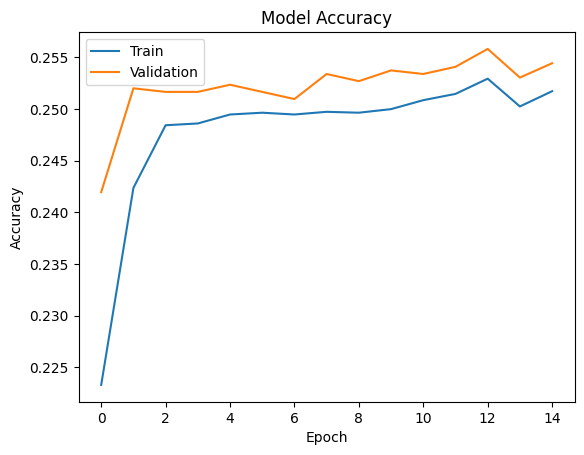

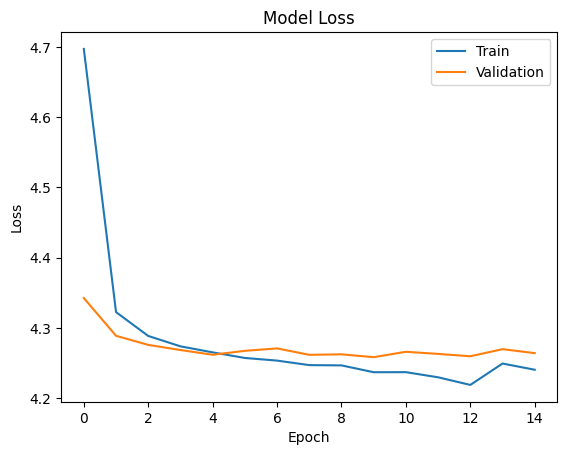

In [ ]:
plot_graph(history)

In [ ]:
sample_text = ""

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

ind_tfidf_df = pd.DataFrame()
for i in [1,2,3]:
    vec_tfidf = TfidfVectorizer(max_features=300, norm='l2', stop_words='english', lowercase=True, use_idf=True, ngram_range=(i,i))
    X = vec_tfidf.fit_transform(ner_df['clean_text']).toarray()
    tfs = pd.DataFrame(X, columns=["TFIDF_" + n for n in vec_tfidf.get_feature_names_out()])
    ind_tfidf_df = pd.concat([ind_tfidf_df.reset_index(drop=True), tfs.reset_index(drop=True)], axis=1)

ind_tfidf_df.head(3)

,TFIDF_account,TFIDF_action,TFIDF_aer,TFIDF_age,TFIDF_air,TFIDF_airline,TFIDF_airport,TFIDF_aklsghxw,TFIDF_alley,TFIDF_american,...,TFIDF_xdyr action aer,TFIDF_xdyr xdyr action,TFIDF_xgyhyckf xgyhyckf version,TFIDF_xjbcmnio xjbcmnio gsjpwm,TFIDF_xo shagthjbk xo,TFIDF_xo xo imjbt,TFIDF_xsbmo ldh xsbmo,TFIDF_yltrnbfx yltrnbfx qlxk,TFIDF_zifcth zifcth xkhdotz,TFIDF_zqnpcxnj zqnpcxnj md
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
ind_tfidf_df.shape

(14422, 900)

In [ ]:
def build_featureset(source_txt, y):
  X_train, X_test, y_train, y_test = train_test_split(source_txt, y, test_size=0.2, stratify=y, random_state=31)
  y_train_encoded = pd.get_dummies(y_train)
  y_test_encoded = pd.get_dummies(y_test)
  token = text.Tokenizer(num_words=None)
  max_len = 185

  token.fit_on_texts(list(X_train) + list(X_test))
  X_train_seq = token.texts_to_sequences(X_train)
  X_test_seq = token.texts_to_sequences(X_test)

  X_train_pad = pad_sequences(X_train_seq, maxlen = max_len)
  X_test_pad = pad_sequences(X_test_seq, maxlen = max_len)
  word_index = token.word_index


In [ ]:
build_featureset(ind_tfidf_df, y)

In [ ]:
embedding_matrix = np.zeros((len(word_index) + 1, 300))
for word, i in tqdm(word_index.items()):
    embedding_vector = embeddings_index.get(word)
    if embedding_vector is not None:
        embedding_matrix[i] = embedding_vector

100%|██████████| 29550/29550 [00:00<00:00, 767687.94it/s]


In [ ]:
model = Sequential()
model.add(Embedding(len(word_index) + 1, 300, weights=[embedding_matrix],input_length=max_len,trainable=False))
model.add(LSTM(1024, return_sequences=True))#, dropout=0.3, recurrent_dropout=0.3))
model.add(LSTM(512, return_sequences=True))
model.add(LSTM(256))
model.add(Dense(256, activation='softmax'))
model.compile(loss='categorical_crossentropy', optimizer='adam',metrics=['accuracy'])
early_stopping = EarlyStopping(monitor='val_loss', patience=5,restore_best_weights=True)
model.summary()

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_5 (Embedding)     (None, 185, 300)          8865300   
                                                                 
 lstm_15 (LSTM)              (None, 185, 1024)         5427200   
                                                                 
 lstm_16 (LSTM)              (None, 185, 512)          3147776   
                                                                 
 lstm_17 (LSTM)              (None, 256)               787456    
                                                                 
 dense_5 (Dense)             (None, 256)               65792     
                                                                 
Total params: 18,293,524
Trainable params: 9,428,224
Non-trainable params: 8,865,300
_________________________________________________________________


In [ ]:
history = model.fit(X_train_pad, y_train_encoded, epochs=50, batch_size=32, validation_data=
                    (X_test_pad, y_test_encoded), callbacks=[early_stopping])

Epoch 1/50
361/361 [==============================] - 17s 36ms/step - loss: 4.5434 - accuracy: 0.2319 - val_loss: 4.3305 - val_accuracy: 0.2416
Epoch 2/50
361/361 [==============================] - 12s 33ms/step - loss: 4.3321 - accuracy: 0.2396 - val_loss: 4.3217 - val_accuracy: 0.2419
Epoch 3/50
361/361 [==============================] - 12s 32ms/step - loss: 4.2982 - accuracy: 0.2459 - val_loss: 4.2765 - val_accuracy: 0.2516
Epoch 4/50
361/361 [==============================] - 12s 33ms/step - loss: 4.2810 - accuracy: 0.2487 - val_loss: 4.2703 - val_accuracy: 0.2516
Epoch 5/50
361/361 [==============================] - 12s 33ms/step - loss: 4.2686 - accuracy: 0.2497 - val_loss: 4.2627 - val_accuracy: 0.2523
Epoch 6/50
361/361 [==============================] - 12s 32ms/step - loss: 4.2620 - accuracy: 0.2501 - val_loss: 4.2592 - val_accuracy: 0.2541
Epoch 7/50
361/361 [==============================] - 12s 32ms/step - loss: 4.2559 - accuracy: 0.2509 - val_loss: 4.2663 - val_accuracy:

In [ ]:
loss, accuracy = model.evaluate(X_test_pad, y_test_encoded)

91/91 [==============================] - 1s 15ms/step - loss: 4.2571 - accuracy: 0.2551


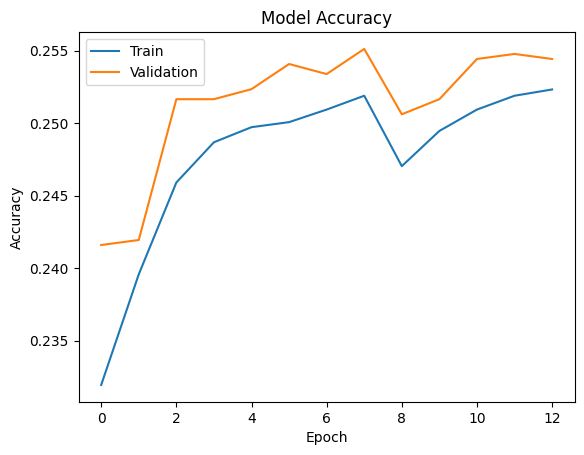

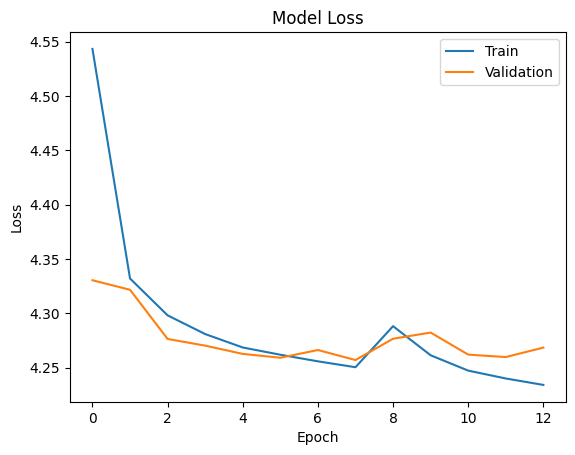

In [ ]:
plot_graph(history)